In [19]:
import numpy as np

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("carbon_factor_dataset.csv")


In [3]:
print(df.head())

   transportation_kgco2_per_km  electricity_kgco2_per_kwh  \
0                     0.206218                   0.803622   
1                     0.246550                   0.878009   
2                     0.231240                   0.550281   
3                     0.221906                   0.774924   
4                     0.190921                   0.743048   

   diet_kgco2_per_meal  waste_kgco2_per_kg  region_factor  \
0             4.417156            0.674073       1.096292   
1             2.275739            0.557608       0.924010   
2             5.425776            0.617473       0.972699   
3             4.259023            0.530814       1.132104   
4             2.207417            0.589010       1.058606   

   total_emission_index  
0           4293.160032  
1           2875.308895  
2           3440.289805  
3           4078.485531  
4           2884.937262  


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   transportation_kgco2_per_km  3000 non-null   float64
 1   electricity_kgco2_per_kwh    3000 non-null   float64
 2   diet_kgco2_per_meal          3000 non-null   float64
 3   waste_kgco2_per_kg           3000 non-null   float64
 4   region_factor                3000 non-null   float64
 5   total_emission_index         3000 non-null   float64
dtypes: float64(6)
memory usage: 140.8 KB
None


In [5]:
print(df.describe())

       transportation_kgco2_per_km  electricity_kgco2_per_kwh  \
count                  3000.000000                3000.000000   
mean                      0.214993                   0.696589   
std                       0.020416                   0.172454   
min                       0.180001                   0.400018   
25%                       0.197206                   0.547437   
50%                       0.215375                   0.692823   
75%                       0.232803                   0.843154   
max                       0.249980                   0.999735   

       diet_kgco2_per_meal  waste_kgco2_per_kg  region_factor  \
count          3000.000000         3000.000000    3000.000000   
mean              3.693264            0.550774       1.049593   
std               1.285131            0.086476       0.087134   
min               1.501085            0.400016       0.900361   
25%               2.586602            0.476357       0.973190   
50%               3.6710

In [24]:
df.head()

,transportation_kgco2_per_km,electricity_kgco2_per_kwh,diet_kgco2_per_meal,waste_kgco2_per_kg,region_factor,total_emission_index
0,0.206218,0.803622,4.417156,0.674073,1.096292,4293.160032
1,0.246550,0.878009,2.275739,0.557608,0.924010,2875.308895
2,0.231240,0.550281,5.425776,0.617473,0.972699,3440.289805
3,0.221906,0.774924,4.259023,0.530814,1.132104,4078.485531
4,0.190921,0.743048,2.207417,0.589010,1.058606,2884.937262


In [25]:
df.shape

(3000, 6)

In [26]:
df.isnull().sum()

transportation_kgco2_per_km    0
electricity_kgco2_per_kwh      0
diet_kgco2_per_meal            0
waste_kgco2_per_kg             0
region_factor                  0
total_emission_index           0
dtype: int64

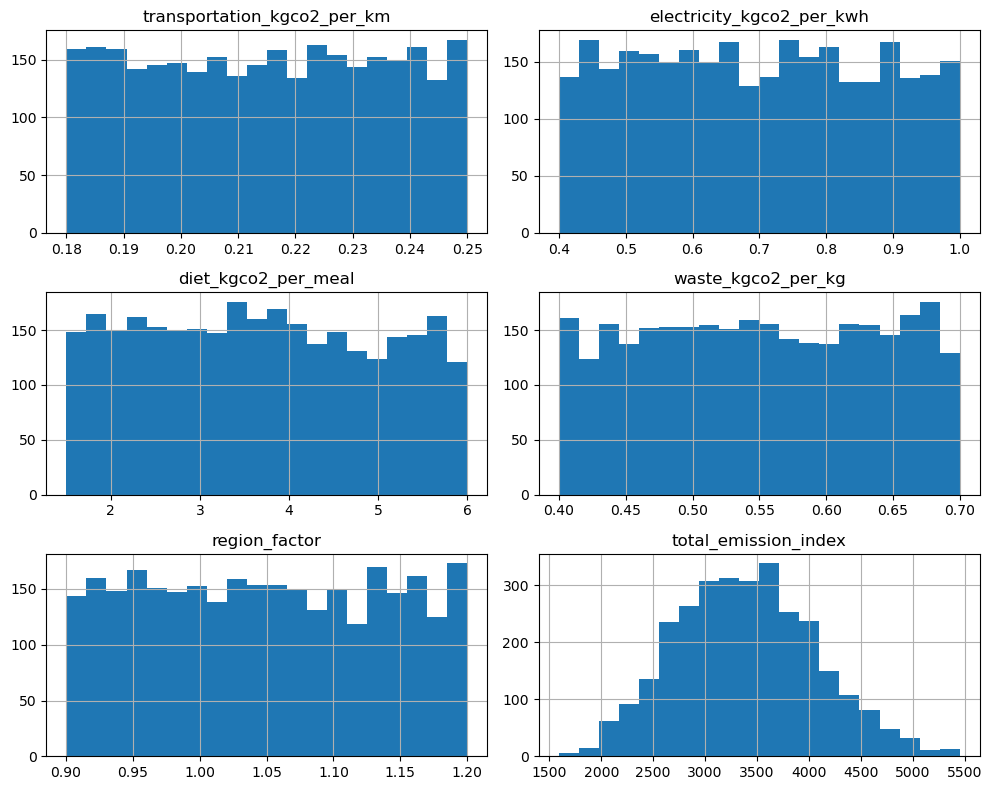

In [28]:
df.hist(figsize=(10,8), bins=20)
plt.tight_layout()
plt.show()

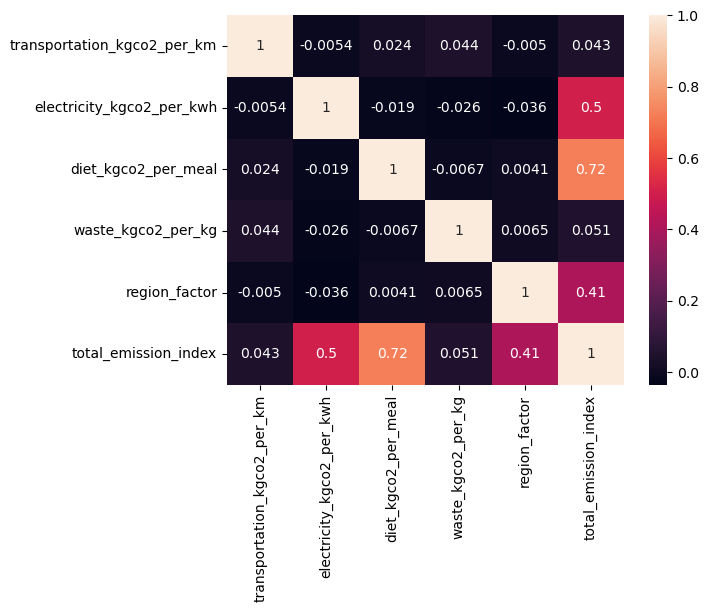

In [6]:
sns.heatmap(df.corr(), annot=True)
plt.show()

In [7]:
X = df.drop("total_emission_index", axis=1)
y = df["total_emission_index"]

In [10]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
lr = LinearRegression()

In [15]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
from sklearn.ensemble import RandomForestRegressor

In [17]:
rf = RandomForestRegressor()

In [18]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
def evaluate(model):
    pred = model.predict(X_test)
    print("MAE:", mean_absolute_error(y_test, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print("R2:", r2_score(y_test, pred))


In [22]:
print("Linear Regression")
evaluate(lr)

Linear Regression
MAE: 90.54736756894118
RMSE: 113.82430773635357
R2: 0.9705525386054183


In [23]:
print("\nRandom Forest")
evaluate(rf)


Random Forest
MAE: 104.12631416087133
RMSE: 128.02443358205855
R2: 0.9627468027548064


In [41]:
coefficients = lr.coef_
features = [
    "Transport",
    "Electricity",
    "Diet",
    "Waste",
    "Region"
]

importance = dict(zip(features, coefficients))

In [42]:
importance

{'Transport': np.float64(832.1407389613888),
 'Electricity': np.float64(2075.6127852870673),
 'Diet': np.float64(382.9154040412311),
 'Waste': np.float64(497.22210838661925),
 'Region': np.float64(3289.579339342097)}

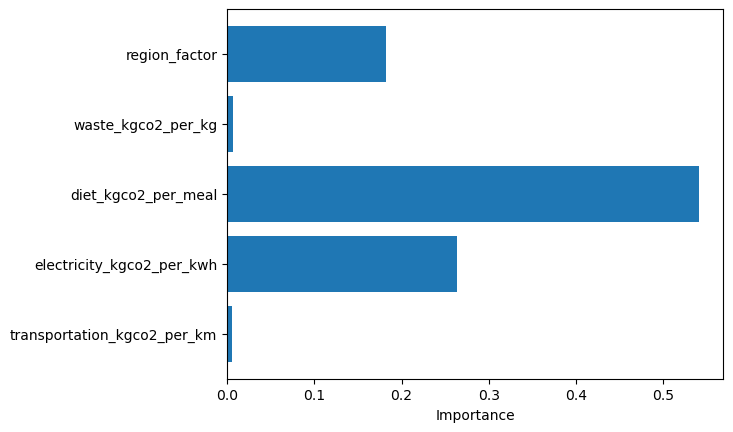

In [36]:
importances = rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.show()



In [32]:
import pickle

with open("carbon_model.pkl", "wb") as f:
    pickle.dump(lr, f)